In [6]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

In [7]:
final_dataset = pd.read_csv('Seoul_Mosquito_Final_Dataset.csv')
final_dataset.head()

,tm,mosquito_value_house,mosquito_value_park,STN,WS_AVG,WR_DAY,WD_MAX,WS_MAX,WS_MAX_TM,WD_INS,...,TE_15,TE_30,TE_50,날짜,수온,pH,용존산소(㎎/L),총질소(㎎/L),총인(㎎/L),총유기탄소
0,20200501,32.6,47.0,108,2.7,2328,29,5.5,1726,29,...,12.6,12.8,13.4,2020-05-01,21.298611,7.298611,6.229167,8.086181,0.116528,6.862500
1,20200502,36.6,52.7,108,2.3,1985,23,4.6,111,29,...,12.7,12.8,13.4,2020-05-02,21.418056,7.183333,5.615278,7.697153,0.201667,5.084722
2,20200503,43.0,62.0,108,2.0,1705,16,3.9,1242,14,...,12.9,12.9,13.4,2020-05-03,22.005556,7.166667,5.736111,7.444375,0.200139,5.004167
3,20200504,43.2,62.3,108,2.7,2310,27,4.6,1247,27,...,13.0,12.9,13.4,2020-05-04,23.216667,7.169444,5.648611,7.402917,0.144861,5.172348
4,20200505,46.7,67.3,108,1.9,1601,25,5.3,1354,23,...,13.2,12.9,13.4,2020-05-05,20.429167,7.102778,5.350000,7.886250,0.209861,5.837500


In [17]:
features = [
    'TA_AVG', 'TD_AVG', 'PV_AVG', 'TS_AVG', 'SS_DUR', 
    'TE_05', 'HM_MIN', 'CA_TOT', '수온', 'pH', '용존산소(㎎/L)'
]

# 2. 타겟 리스트
targets = ['mosquito_value_park', 'mosquito_value_house']


# 3. 데이터 분리 (예: Park 모델용 데이터)
df_park = final_dataset[features + ['mosquito_value_park']].copy()
# 데이터프레임의 마지막 컬럼 이름 확인
print("현재 설정된 타겟(y) 컬럼:", df_park.columns[-1])


df_house = final_dataset[features + ['mosquito_value_house']].copy()
# 데이터프레임의 마지막 컬럼 이름 확인
print("현재 설정된 타겟(y) 컬럼:", df_house.columns[-1])

현재 설정된 타겟(y) 컬럼: mosquito_value_park
현재 설정된 타겟(y) 컬럼: mosquito_value_house


In [18]:
def s_train_val_test(df, target_col):
    # 9:1:1 분할 (이전 코드 활용)
    n = len(df)
    train_end = int(n * 0.82)
    val_end = int(n * 0.91)
    
    train = df.iloc[:train_end]
    val = df.iloc[train_end:val_end]
    test = df.iloc[val_end:]
    
    return train, val, test

def s_train_val_test(df):
    # 9:1:1 분할 (이전 코드 활용)
    n = len(df)
    train_end = int(n * 0.82)
    val_end = int(n * 0.91)
    
    train = df.iloc[:train_end]
    val = df.iloc[train_end:val_end]
    test = df.iloc[val_end:]
    
    # 해당 타겟 전용 스케일러 생성 및 적용
    scaler = MinMaxScaler()
    scaled_train = scaler.fit_transform(train)
    scaled_val = scaler.transform(val)
    scaled_test = scaler.transform(test)
    
    return scaled_train, scaled_val, scaled_test, scaler


s_park_train, s_park_val, s_park_test, park_scaler = s_train_val_test(df_park)
s_house_train, s_house_val, s_house_test, house_scaler = s_train_val_test(df_house)
print(f"Train: {len(s_park_train)}, Val: {len(s_park_val)}, Test: {len(s_park_test)}")
print(f"Train: {len(s_house_train)}, Val: {len(s_house_val)}, Test: {len(s_house_test)}")

Train: 896, Val: 98, Test: 99
Train: 896, Val: 98, Test: 99


In [21]:
def create_sequences(data, window_size=14):
    X, y = [], []
    for i in range(len(data) - window_size):
        # i부터 i+window_size 전까지는 입력 피처 (X)
        X.append(data[i:i+window_size, :-1]) 
        # i+window_size 시점의 마지막 컬럼은 정답 (y)
        y.append(data[i+window_size, -1])
    return np.array(X), np.array(y)

# Park 데이터셋 적용 (House도 동일하게 반복 가능)
window_size = 14
X_park_train, y_park_train = create_sequences(s_park_train, window_size)
X_park_val, y_park_val = create_sequences(s_park_val, window_size)
X_park_test, y_park_test = create_sequences(s_park_test, window_size)

print(f"학습 데이터 형태: {X_park_train.shape}") # (샘플 수, 14, 피처 수)

window_size = 14
X_house_train, y_house_train = create_sequences(s_park_train, window_size)
X_house_val, y_house_val = create_sequences(s_park_val, window_size)
X_house_test, y_house_test = create_sequences(s_park_test, window_size)

print(f"학습 데이터 형태: {X_house_train.shape}") # (샘플 수, 14, 피처 수)

학습 데이터 형태: (882, 14, 11)
학습 데이터 형태: (882, 14, 11)


In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

# 모델 구조 정의
park_model_rnn = Sequential([
    # 1층 RNN: 시퀀스 데이터를 받아 처리
    SimpleRNN(64, return_sequences=True, input_shape=(X_park_train.shape[1], X_park_train.shape[2])),
    Dropout(0.2),
    # 2층 RNN: 좀 더 복잡한 패턴 학습
    SimpleRNN(32),
    Dropout(0.2),
    # 출력층: 최종 수치 예측
    Dense(16, activation='relu'),
    Dense(1)
])

park_model_rnn.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 학습 시작
park_history = park_model_rnn.fit(
    X_park_train, y_park_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_park_val, y_park_val),
    verbose=1
)

Epoch 1/50
28/28 [==============================] - 1s 8ms/step - loss: 0.1551 - mae: 0.3092 - val_loss: 0.0459 - val_mae: 0.1779
Epoch 2/50
28/28 [==============================] - 0s 3ms/step - loss: 0.0825 - mae: 0.2288 - val_loss: 0.0292 - val_mae: 0.1332
Epoch 3/50
28/28 [==============================] - 0s 3ms/step - loss: 0.0587 - mae: 0.1929 - val_loss: 0.0547 - val_mae: 0.1944
Epoch 4/50
28/28 [==============================] - 0s 3ms/step - loss: 0.0503 - mae: 0.1801 - val_loss: 0.0208 - val_mae: 0.1129
Epoch 5/50
28/28 [==============================] - 0s 3ms/step - loss: 0.0433 - mae: 0.1656 - val_loss: 0.0280 - val_mae: 0.1315
Epoch 6/50
28/28 [==============================] - 0s 3ms/step - loss: 0.0367 - mae: 0.1520 - val_loss: 0.0320 - val_mae: 0.1421
Epoch 7/50
28/28 [==============================] - 0s 3ms/step - loss: 0.0315 - mae: 0.1396 - val_loss: 0.0254 - val_mae: 0.1238
Epoch 8/50
28/28 [==============================] - 0s 3ms/step - loss: 0.0257 - mae: 0.12

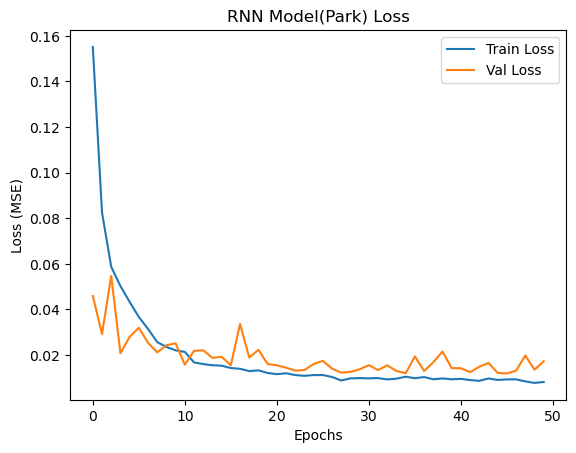

In [29]:
import matplotlib.pyplot as plt

plt.plot(park_history.history['loss'], label='Train Loss')
plt.plot(park_history.history['val_loss'], label='Val Loss')
plt.title('RNN Model(Park) Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

In [30]:
# 모델 구조 정의
house_model_rnn = Sequential([
    # 1층 RNN: 시퀀스 데이터를 받아 처리
    SimpleRNN(64, return_sequences=True, input_shape=(X_house_train.shape[1], X_house_train.shape[2])),
    Dropout(0.2),
    # 2층 RNN: 좀 더 복잡한 패턴 학습
    SimpleRNN(32),
    Dropout(0.2),
    # 출력층: 최종 수치 예측
    Dense(16, activation='relu'),
    Dense(1)
])

house_model_rnn.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 학습 시작
house_history = house_model_rnn.fit(
    X_house_train, y_house_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_house_val, y_house_val),
    verbose=1
)

Epoch 1/50
28/28 [==============================] - 1s 8ms/step - loss: 0.1371 - mae: 0.2949 - val_loss: 0.0295 - val_mae: 0.1372
Epoch 2/50
28/28 [==============================] - 0s 3ms/step - loss: 0.0561 - mae: 0.1888 - val_loss: 0.0282 - val_mae: 0.1386
Epoch 3/50
28/28 [==============================] - 0s 3ms/step - loss: 0.0367 - mae: 0.1518 - val_loss: 0.0280 - val_mae: 0.1330
Epoch 4/50
28/28 [==============================] - 0s 3ms/step - loss: 0.0307 - mae: 0.1357 - val_loss: 0.0230 - val_mae: 0.1174
Epoch 5/50
28/28 [==============================] - 0s 3ms/step - loss: 0.0263 - mae: 0.1246 - val_loss: 0.0204 - val_mae: 0.1073
Epoch 6/50
28/28 [==============================] - 0s 3ms/step - loss: 0.0234 - mae: 0.1190 - val_loss: 0.0199 - val_mae: 0.1084
Epoch 7/50
28/28 [==============================] - 0s 3ms/step - loss: 0.0196 - mae: 0.1089 - val_loss: 0.0214 - val_mae: 0.1141
Epoch 8/50
28/28 [==============================] - 0s 3ms/step - loss: 0.0179 - mae: 0.10

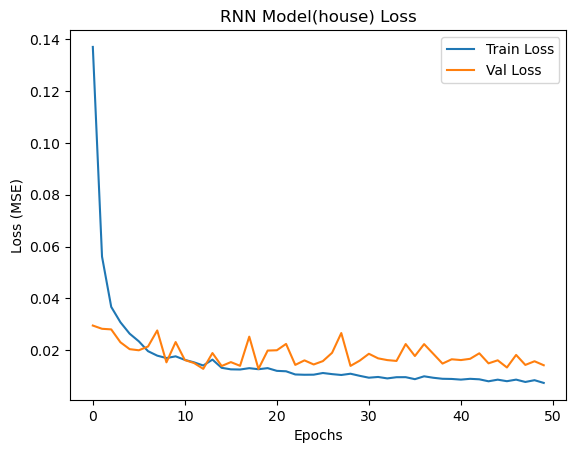

In [31]:
import matplotlib.pyplot as plt

plt.plot(house_history.history['loss'], label='Train Loss')
plt.plot(house_history.history['val_loss'], label='Val Loss')
plt.title('RNN Model(house) Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

def build_lstm_model(input_shape):
    model = Sequential([
        # 장기 기억을 위한 LSTM 레이어
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    # 학습률을 약간 낮춰(0.0005) 진동을 방지합니다.
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

# 조기 종료 설정: val_loss가 7회 연속 안 좋아지면 멈춤
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

# 1. Park용 LSTM 학습
model_lstm_park = build_lstm_model((X_park_train.shape[1], X_park_train.shape[2]))
# history_p = model_lstm_park.fit(X_park_train, y_park_train, epochs=100, batch_size=32,
#                                 validation_data=(X_park_val, y_park_val), callbacks=[early_stop])
history_p = model_lstm_park.fit(X_park_train, y_park_train, epochs=100, batch_size=32,
                                validation_data=(X_park_val, y_park_val))

Epoch 1/100
28/28 [==============================] - 2s 19ms/step - loss: 0.1130 - mae: 0.2639 - val_loss: 0.0491 - val_mae: 0.1960
Epoch 2/100
28/28 [==============================] - 0s 5ms/step - loss: 0.0270 - mae: 0.1308 - val_loss: 0.0353 - val_mae: 0.1622
Epoch 3/100
28/28 [==============================] - 0s 5ms/step - loss: 0.0193 - mae: 0.1066 - val_loss: 0.0340 - val_mae: 0.1511
Epoch 4/100
28/28 [==============================] - 0s 5ms/step - loss: 0.0174 - mae: 0.1034 - val_loss: 0.0275 - val_mae: 0.1325
Epoch 5/100
28/28 [==============================] - 0s 5ms/step - loss: 0.0168 - mae: 0.0995 - val_loss: 0.0337 - val_mae: 0.1511
Epoch 6/100
28/28 [==============================] - 0s 5ms/step - loss: 0.0149 - mae: 0.0941 - val_loss: 0.0209 - val_mae: 0.1092
Epoch 7/100
28/28 [==============================] - 0s 5ms/step - loss: 0.0139 - mae: 0.0908 - val_loss: 0.0200 - val_mae: 0.1063
Epoch 8/100
28/28 [==============================] - 0s 5ms/step - loss: 0.0137 - 

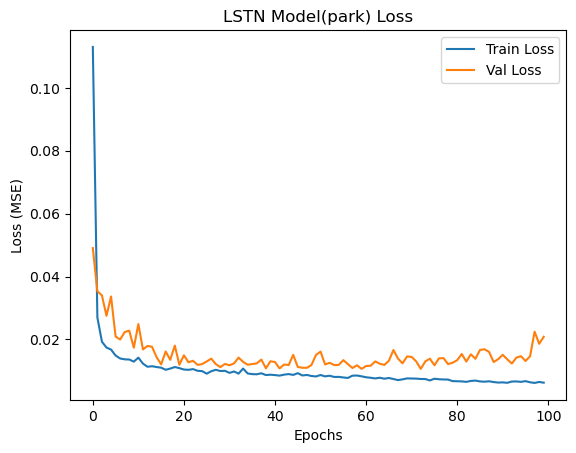

In [47]:
import matplotlib.pyplot as plt

plt.plot(history_p.history['loss'], label='Train Loss')
plt.plot(history_p.history['val_loss'], label='Val Loss')
plt.title('LSTN Model(park) Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

3/3 [==============================] - 0s 2ms/step


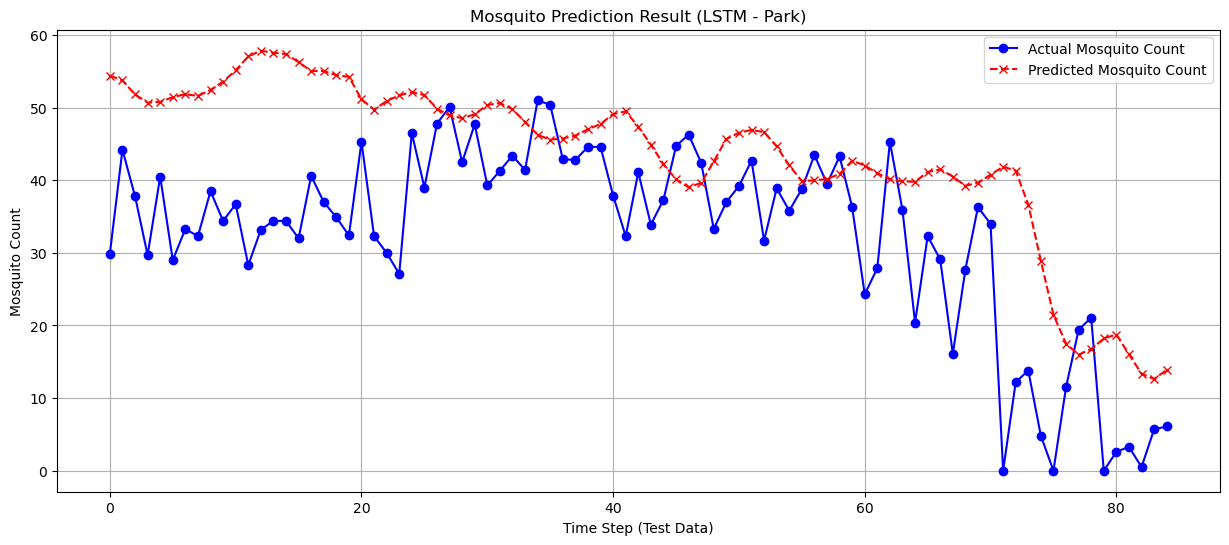

In [40]:
# 1. 테스트 데이터 예측
y_pred = model_lstm_park.predict(X_park_test)

# 2. 스케일링 역변환 (원래 마릿수로 복원)
# 예측값(y_pred)과 실제값(y_park_test) 모두 (85, 1) 형태로 확보합니다.
y_pred = y_pred.reshape(-1, 1)
y_actual = y_park_test.reshape(-1, 1)

# [수정 포인트] np.zeros의 열 개수는 'len(features)'여야 총 합이 (피처 + 타겟)이 됩니다.
# len(features)가 11개라면, 11개의 0 + 1개의 예측값 = 총 12개 컬럼 (스케일러 규격)

y_pred_rescaled = park_scaler.inverse_transform(
    np.concatenate([np.zeros((len(y_pred), len(features))), y_pred], axis=1)
)[:, -1]

y_actual_rescaled = park_scaler.inverse_transform(
    np.concatenate([np.zeros((len(y_actual), len(features))), y_actual], axis=1)
)[:, -1]

# 3. 결과 시각화
plt.figure(figsize=(15, 6))
plt.plot(y_actual_rescaled, label='Actual Mosquito Count', color='blue', marker='o')
plt.plot(y_pred_rescaled, label='Predicted Mosquito Count', color='red', linestyle='--', marker='x')
plt.title('Mosquito Prediction Result (LSTM - Park)')
plt.ylabel('Mosquito Count')
plt.xlabel('Time Step (Test Data)')
plt.legend()
plt.grid(True)
plt.show()

In [44]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

def build_lstm_model(input_shape):
    model = Sequential([
        # 장기 기억을 위한 LSTM 레이어
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    # 학습률을 약간 낮춰(0.0005) 진동을 방지합니다.
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

# 조기 종료 설정: val_loss가 7회 연속 안 좋아지면 멈춤
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

# 1. Park용 LSTM 학습
model_lstm_house = build_lstm_model((X_house_train.shape[1], X_house_train.shape[2]))
# history_p = model_lstm_park.fit(X_park_train, y_park_train, epochs=100, batch_size=32,
#                                 validation_data=(X_park_val, y_park_val), callbacks=[early_stop])
history_h = model_lstm_park.fit(X_house_train, y_house_train, epochs=100, batch_size=32,
                                validation_data=(X_house_val, y_house_val))

Epoch 1/100
28/28 [==============================] - 0s 5ms/step - loss: 0.0043 - mae: 0.0472 - val_loss: 0.0196 - val_mae: 0.1007
Epoch 2/100
28/28 [==============================] - 0s 5ms/step - loss: 0.0044 - mae: 0.0471 - val_loss: 0.0188 - val_mae: 0.0984
Epoch 3/100
28/28 [==============================] - 0s 5ms/step - loss: 0.0042 - mae: 0.0465 - val_loss: 0.0153 - val_mae: 0.0886
Epoch 4/100
28/28 [==============================] - 0s 5ms/step - loss: 0.0041 - mae: 0.0466 - val_loss: 0.0156 - val_mae: 0.0894
Epoch 5/100
28/28 [==============================] - 0s 4ms/step - loss: 0.0043 - mae: 0.0473 - val_loss: 0.0171 - val_mae: 0.0935
Epoch 6/100
28/28 [==============================] - 0s 5ms/step - loss: 0.0042 - mae: 0.0456 - val_loss: 0.0244 - val_mae: 0.1145
Epoch 7/100
28/28 [==============================] - 0s 5ms/step - loss: 0.0044 - mae: 0.0466 - val_loss: 0.0222 - val_mae: 0.1073
Epoch 8/100
28/28 [==============================] - 0s 5ms/step - loss: 0.0044 - m

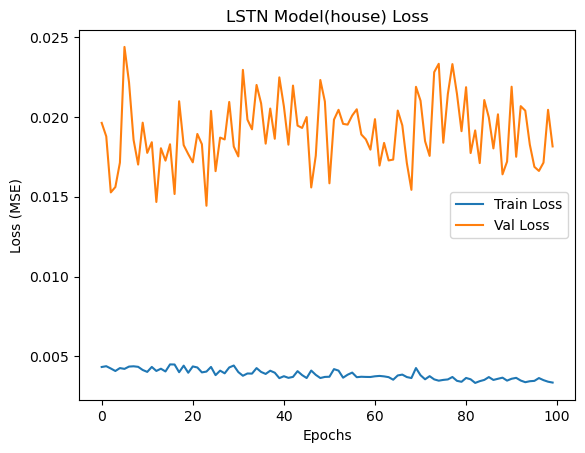

In [45]:
import matplotlib.pyplot as plt

plt.plot(history_h.history['loss'], label='Train Loss')
plt.plot(history_h.history['val_loss'], label='Val Loss')
plt.title('LSTN Model(house) Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

3/3 [==============================] - 0s 2ms/step


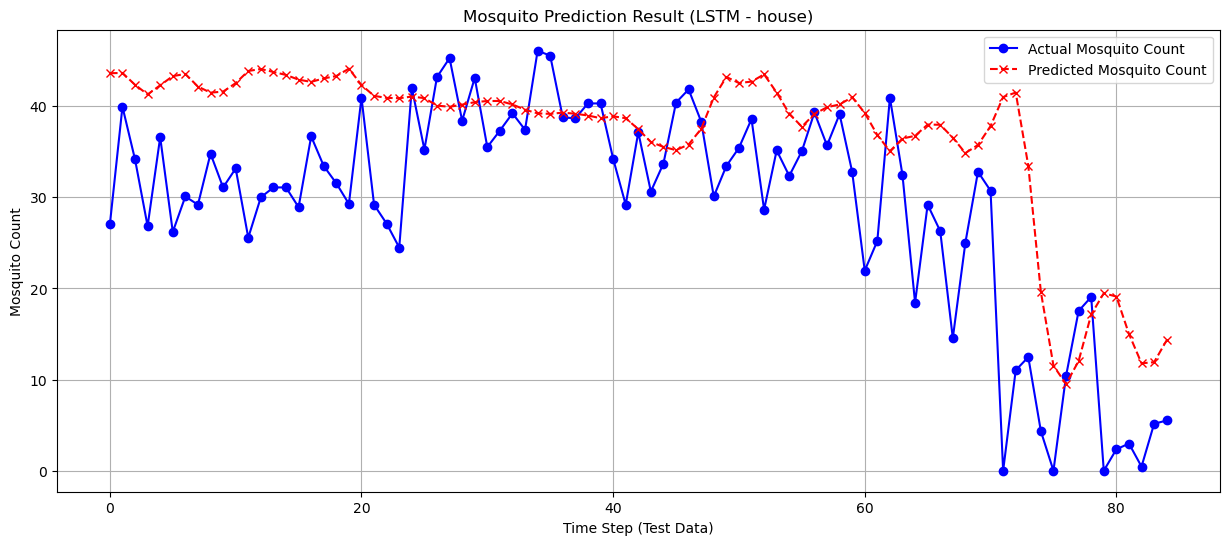

In [46]:
# 1. 테스트 데이터 예측
y_pred = model_lstm_park.predict(X_house_test)

# 2. 스케일링 역변환 (원래 마릿수로 복원)
# 예측값(y_pred)과 실제값(y_park_test) 모두 (85, 1) 형태로 확보합니다.
y_pred = y_pred.reshape(-1, 1)
y_actual = y_house_test.reshape(-1, 1)

# [수정 포인트] np.zeros의 열 개수는 'len(features)'여야 총 합이 (피처 + 타겟)이 됩니다.
# len(features)가 11개라면, 11개의 0 + 1개의 예측값 = 총 12개 컬럼 (스케일러 규격)

y_pred_rescaled = house_scaler.inverse_transform(
    np.concatenate([np.zeros((len(y_pred), len(features))), y_pred], axis=1)
)[:, -1]

y_actual_rescaled = house_scaler.inverse_transform(
    np.concatenate([np.zeros((len(y_actual), len(features))), y_actual], axis=1)
)[:, -1]

# 3. 결과 시각화
plt.figure(figsize=(15, 6))
plt.plot(y_actual_rescaled, label='Actual Mosquito Count', color='blue', marker='o')
plt.plot(y_pred_rescaled, label='Predicted Mosquito Count', color='red', linestyle='--', marker='x')
plt.title('Mosquito Prediction Result (LSTM - house)')
plt.ylabel('Mosquito Count')
plt.xlabel('Time Step (Test Data)')
plt.legend()
plt.grid(True)
plt.show()